# Lagged Predictions of Next Week Alcohol Use for Precision Mental

Health Support

Kendra Wyant (Department of Psychology, University of Wisconsin-Madison)  
Gaylen E. Fronk (Department of Psychology, University of Wisconsin-Madison)  
Jiachen Yu (Department of Psychology, University of Wisconsin-Madison)  
John J. Curtin (Department of Psychology, University of Wisconsin-Madison)  
July 31, 2024

This study found some pretty cool results that have both high impact and important clinical implications. For example …

In [ ]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(source("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true"))
suppressPackageStartupMessages(library(tidyposterior))
library(kableExtra, exclude = "group_rows")

path_models_lag <- format_path(str_c("studydata/risk/models/lag"))
path_processed <- format_path("studydata/risk/data_processed/lag")

options(knitr.kable.NA = '')

In [ ]:
# read in tibbles for in-line code

test_metrics_all_perf <- read_csv(here::here(path_models_lag, "test_metrics_all.csv"), 
                                  col_types = cols())

test_metrics_all_pp_perf <- read_csv(here::here(path_models_lag, "test_metrics_all_pp_perf.csv"), 
                                     col_types = cols())

ci_baseline <- read_csv(here::here(path_models_lag, "ci_baseline.csv"), 
                        col_types = cols())

ci_lag <- read_csv(here::here(path_models_lag, "ci_lag.csv"), col_types = cols())

pp_dem <- read_csv(here::here(path_models_lag, "pp_dem_all.csv"), col_types = cols())

pp_dem_contrast <- read_csv(here::here(path_models_lag, "pp_dem_contrast_all.csv"), col_types = cols())

screen <- read_csv(here::here(path_processed, "dem_tibble.csv"),
                   col_types = cols())

lapses_per_subid <- read_csv(here::here(path_processed, "lapse_tibble.csv"),
                             col_types = cols())

# Introduction

Precision medicine has been a goal in healthcare for over half a century \[@derubeisHistoryCurrentStatus2019\]. Traditionally, precision medicine seeks to answer the question of *how* we best treat a specific individual, given their unique combination of genetic, lifestyle, and environmental characteristics (e.g., which medication is most effective for whom).

Today, this approach is also applied to chronic mental health conditions (i.e., precision mental health) such as depression, substance use disorders, and suicide. Mental health conditions are complex, fluctuating processes. Medical conditions often have clear biological precursors, which may be treated well with a single medication. In contrast, mental health conditions are products of numerous psychosocial factors, and treatments must be selected from a wide array of psychosocial supports. Moreover, the factors driving mental health conditions differ between individuals and can change within an individual over time. Thus, precision mental health must consider both the *how* and the *when* (e.g., which treatment is most effective for whom at what moment).

There has been long-standing interest in precision mental health and substance use disorders. An early example is the Project MATCH research group, which attempted to match individuals with alcohol use disorder to their optimal treatment based on baseline measures of individual characteristics \[@projectmatchresearchgroupMatchingAlcoholismTreatments1997\]. The study did not find any differences in treatment success. This can likely be attributed to 1) low-dimensional analyses that failed to capture the complex and heterogeneous nature of substance use disorders; and 2) their use of static distal features to predict a non-linear, time-varying course of recovery, lapse, and relapse \[@witkiewitzModelingComplexityPosttreatment2007\]. In other words, they used overly simplistic models to address the question of *how* and did not consider the question of *when*.<!-- GEF: i added the 1 & 2 to help make that first sentence more readable. however, i'm wondering if breaking it up the other way would be clearest - sentence 1 is low dimensional analyses -> overly simplistic models to address the question of how; sentence 2 is using static distal features -> not considering the question of when -->

The *when* is particularly important for predicting discrete symptoms or behaviors. Take the example of lapses, discrete instances of goal inconsistent substance use. Lapses are a clinically important target for substance use treatment. They are often an early warning sign of relapse, and maladaptive responses to lapses can undermine recovery. For some substances, even a single lapse can result in an overdose and/or death. It would be unreasonable to expect that we could predict a lapse with any temporal precision using only features that become more distal as time progresses. Rather, lapse prediction requires dense, long-term monitoring of symptoms and related states proximal to the outcome.

Recent advances in both personal sensing and machine learning may address these barriers to successful precision mental health. Personal sensing allows for frequent, longitudinal measurement of changes in proximal risk (e.g., for a lapse) with high temporal precision. Machine learning uses high dimensional inputs that can capture the complexity of mental health conditions. Moreover, tools from machine learning can be applied to models to understand which factors are important to a specific individual at a specific moment in time.

Ecological momentary assessment (EMA) may be particularly well-suited for these algorithms. It offers momentary subjective insight into constructs that can be easily mapped onto modular forms of treatment, such as the relapse prevention model \[@marlattRelapsePreventionMaintenance1985; @witkiewitzRelapsePreventionAlcohol2004\]. EMA also appears to be well tolerated by individuals with substance use disorders \[@wyantAcceptabilityPersonalSensing2023\]. Thus, it can serve as an important signal for predicting substance use outcomes and interpreting clinically relevant features over a sustained period. <!-- should we break apart the next paragraph into two ideas.  First that we can predict well for serveral different window widths and next that the narrow width immediate windows are good for JIT in a DTx.  Then you can transition to the neeed for more advanced warning for interventions and supports that are not completely digital - txt, support from a friend, etc.--> Promising preliminary work suggests it is possible to build EMA models that predict immediate lapses back to substance use \[@waltersUsingMachineLearning2021; @baeMobilePhoneSensors2018; @soysterPooledPersonspecificMachine2022; @chihPredictiveModelingAddiction2014\]. In a previous study from our group, we demonstrated that we can do this very well. We used 4X daily EMA with questions designed to measure theoretically-implicated risk factors including past use, craving, past pleasant events, past and future risky situations, past and future stressful events, emotional valence and arousal, and self-efficacy. We showed that it was possible to predict immediate alcohol lapses within the next week, day, and hour with clinically meaningful accuracy - area under the receiver operating curves (auROCs) of 0.90, 0.91, and 0.93, respectively \[@wyantMachineLearningModels2023\]. We also characterized the relative importance of features contributing to these risk probabilities for specific individuals at specific moments in time. These models are well-suited to make algorithm-guided recommendations to address immediate risks - for example, recommending a coping with craving activity when someone has increased craving, or recommending a guided relaxation video when someone is reporting recent stressful events. Importantly, these supports can be available 24/7 (e.g., in a digital therapeutic) for an individual, allowing them to take action right away.

However, many interventions cannot be self-contained in a digital therapeutic and take time to set up. For example, someone who has reported recent past alcohol use and low abstinence self-efficacy might be encouraged to attend a self-help meeting, plan an outing with important people in their life, or schedule an appointment with a therapist. These multimodal interventions (i.e., combined human and digital interventions) are not available 24/7. A *time-lagged* model with predictions shifted further into the future could provide patients with increased lead time to implement supports that might not be immediately available to them.

In this study, we compared the performance of one of our models from a previous study \[@wyantMachineLearningModels2023\] with models using increased lag time between predictions and outcomes. Specifically, we used the same EMA features as our immediate model and train new models to predict the probability of a lapse beginning one day (24 hours), three days (72 hours), one week (168 hours), or two weeks (336 hours) into the future. Our primary objective was to assess how well models perform with increasing lag time.

# Methods

## Transparency and Openness

We adhere to research transparency principles that are crucial for robust and replicable science. We preregistered our data analytic strategy. We reported how we determined the sample size, all data exclusions, all manipulations, and all study measures. We provide a transparency report in the supplement. Finally, our data, analysis scripts, annotated results, questionnaires, and other study materials are publicly available (<https://osf.io/xta67/>).

## Participants

We recruited participants in early recovery (1-8 weeks of abstinence) from moderate to severe alcohol use disorder in Madison, Wisconsin, US for a three month longitudinal study. One hundred fifty one participants were included in our analyses. We used data from all participants included in our previous study (see \[@wyantMachineLearningModels2023\] for enrollment and disposition information). This sample size was determined based on traditional power analysis methods for logistic regression \[@hsiehSampleSizeTables1989\] because comparable approaches for machine learning models have not yet been validated. Participants were recruited through print and targeted digital advertisements and partnerships with treatment centers. We required that participants:

1.  were age 18 or older,
2.  could write and read in English,
3.  had at least moderate AUD (\>= 4 self-reported DSM-5 symptoms),
4.  were abstinent from alcohol for 1-8 weeks, and
5.  were willing to use a single smartphone (personal or study provided) while on study.

We also excluded participants exhibiting severe symptoms of psychosis or paranoia.

## Procedure

Participants completed five study visits over approximately three months. After an initial phone screen, participants attended an in-person screening visit to determine eligibility, complete informed consent, and collect self-report measures. Eligible, consented participants returned approximately one week later for an intake visit. Three additional follow-up visits occurred about every 30 days that participants remained on study. Participants were expected to complete four daily EMAs while on study. Other personal sensing data streams (geolocation, cellular communications, sleep quality, and audio check-ins) were collected as part of the parent grant’s aims (R01 AA024391).

## Measures

### Ecological Momentary Assessments

Participants completed four brief (7-10 questions) EMAs daily. The first and last EMAs of the day were scheduled within one hour of participants’ typical wake and sleep times. The other two EMAs were scheduled randomly within the first and second halves of their typical day, with at least one hour between EMAs. Participants learned how to complete the EMA and the meaning of each question during their intake visit.

On all EMAs, participants reported dates/times of any unreported past alcohol use. Next, participants rated the maximum intensity of recent (i.e., since last EMA) experiences of craving, risky situations, stressful events, and pleasant events. Finally, participants rated their current affect on two bipolar scales: valence (Unpleasant/Unhappy to Pleasant/Happy) and arousal (Calm/Sleepy to Aroused/Alert).

On the first EMA each day, participants also rated the likelihood of encountering risky situations and stressful events in the next week and the likelihood that they would drink alcohol in the next week (i.e., abstinence self-efficacy).

### Individual Characteristics

We collected self-report information about demographics (age, sex, race, ethnicity, education, marital status, employment, and income) and AUD symptom count.

## Data Analytic Strategy

Data preprocessing, modeling, and Bayesian analyses were done in R using the tidymodels ecosystem \[@kuhnTidymodelsCollectionPackages2020\]. Models were trained and evaluated using high-throughput computing resources provided by the University of Wisconsin Center for High Throughput Computing \[@chtc\].

### Lapse Labels

We predicted lapses occurring in one week windows (@fig-methods). Predictions were updated hourly. Therefore our models provided hour-by-hour predictions of future probability of an alcohol lapse within a one week window shifted at various time points (i.e., lags) into the future (no lag and 24 hour, 72 hour, 168 hour, or 336 hour lagged predictions).

``` python
knitr::include_graphics(path = here::here("figures/methods.jpg"))
```

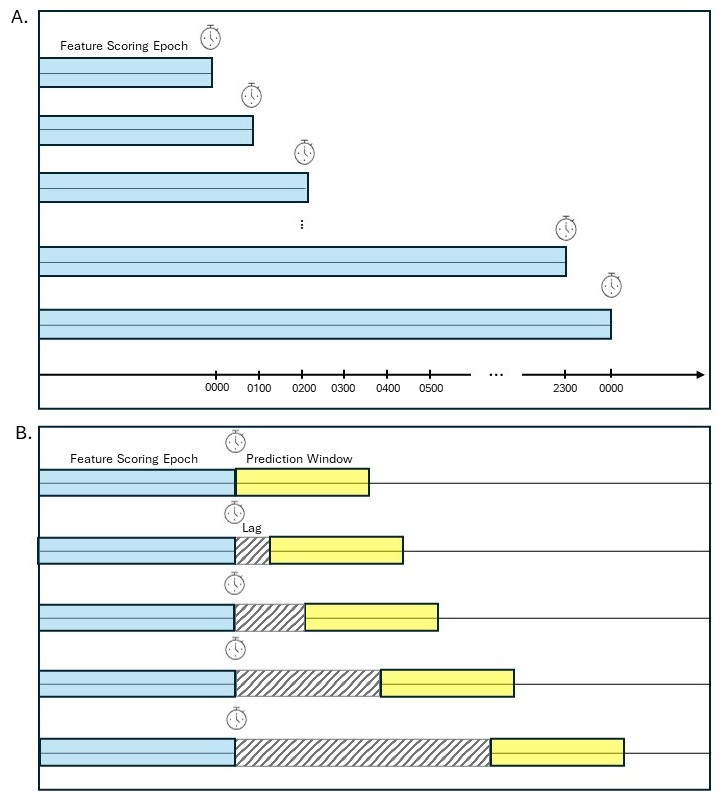

The first prediction window for each participant began 24 hours from midnight on their study start date + lag time. For example, the first prediction for the 24 hour lagged prediction model would be 48 hours after participants’ start date. This ensured at least 24 hours of past EMAs for future lapse prediction in these first windows. Subsequent windows for each participant were created by repeatedly rolling the window start time forward one hour until the end of their study participation (i.e., each participant’s last prediction window started one week before their last recorded EMA).

The start and end date/time of past drinking episodes were reported on the first EMA item. A prediction window was labeled *lapse* if the start date/hour of any drinking episode fell within that window. A window was labeled *no lapse* if no alcohol use occurred within that window +/- 24 hours. If no alcohol use occurred within the window but did occur within 24 hours of the start or end of the window, the window was excluded.

We ended up with a total of 270,081 labels for our baseline (no lag) model, 266,599 labels for our 24 hour lagged model, 259,643 labels for our 72 hour lagged model, 245,707 labels for our 168 hour lagged model, and 221,206 labels for our 336 hour lagged model.

### Feature Engineering

Features were calculated using only data collected before the start of each prediction window to ensure our models were making true future predictions. For our no lag models this included all data prior to the hour of the start of the prediction window. For our lagged models, the last EMA data used for feature engineering were collected up to 24 hours, 72 hours, 168 hours, or 336 hours prior to the start of the prediction window.

A total of 279 features were derived from two data sources:

1.  *Demographics*: We created quantitative features for age and personal income, and dummy-coded features for sex, race/ethnicity, marital status, education, and employment.

2.  *Previous EMA responses*: We created raw EMA and change features for varying scoring epochs (i.e., 12, 24, 48, 72, and 168 hours) before the start of the prediction window for all EMA items. Raw features included min, max, and median scores for each EMA item across all EMAs in each epoch for that participant. We calculated change features by subtracting the participants’ overall mean score for each EMA item (using all EMAs collected before the start of the prediction window) from the associated raw feature. We also created raw and change features based on the most recent response for each EMA question and raw and change rate features from previously reported lapses and number of completed EMAs.

Other generic feature engineering steps included imputing missing data (median imputation for numeric features, mode imputation for nominal features) and removing zero and near-zero variance features as determined from held-in data (see Cross-validation section below).

### Model Training and Evaluation

#### Model Configurations

We trained and evaluated five separate classification models: one baseline (no lag) model and one model for 24 hour, 72 hour, 168 hour, and 336 hour lagged predictions. We considered four well-established statistical algorithms (elastic net, XGBoost, regularized discriminant analysis, and single layer neural networks) that vary across characteristics expected to affect model performance (e.g., flexibility, complexity, handling higher-order interactions natively) \[@kuhnAppliedPredictiveModeling2018\].

Candidate model configurations differed across sensible values for key hyperparameters. They also differed on outcome resampling method (i.e., no resampling and up-sampling and down-sampling of the outcome using majority/no lapse to minority/lapse ratios ranging from 1:1 to 2:1). We calibrated predicted probabilities using the beta distribution to support optimal decision-making under variable outcome distributions \[@kullSigmoidsHowObtain2017\].

#### Cross-validation

We used participant-grouped, nested cross-validation for model training, selection, and evaluation with auROC. auROC indexes the probability that the model will predict a higher score for a randomly selected positive case (lapse) relative to a randomly selected negative case (no lapse). Grouped cross-validation assigns all data from a participant as either held-in or held-out to avoid bias introduced when predicting a participant’s data from their own data. We used 1 repeat of 10-fold cross-validation for the inner loops (i.e., *validation* sets) and 3 repeats of 10-fold cross-validation for the outer loop (i.e., *test* sets). Best model configurations were selected using median auROC across the 10 validation sets. Final performance evaluation of those best model configurations used median auROC across the 30 test sets.

#### Model Evaluation

We used a Bayesian hierarchical generalized linear model to estimate the posterior probability distributions and 95% Bayesian credible intervals (CIs) for auROC for the five best models (no lag and 24 hour, 72 hour, 168 hour, and 336 hour lagged predictions) on the 30 held-out test sets. The median posterior probability for auROC represents our best estimate for the magnitude of the auROC parameter for each model. If the confidence intervals do not contain .5 (chance performance), this suggests our model is capturing signal in the data.

#### Model Comparisons

We performed two sets of Bayesian model comparisons. First, we compared each lagged model to our baseline model (no lag) \[@wyantMachineLearningModels2023\]. We have demonstrated previously that our baseline model performs well. These comparisons show whether we can predict lapses with similar performance with varying lags (i.e., no lag vs. 24 hours, no lag vs. 72 hours, no lag vs. 168 hours, no lag vs. 336 hours).

Second, we compared each adjacent lagged model (i.e., 24 hours vs 72 hours, 72 hours vs. 168 hours, and 168 hours vs. 336 hours). These comparisons allow us to determine the probability that the lagged models systematically differed as predictions were made further into the future.

For both sets of model comparisons, we determined the probability that the models’ performances differed systematically from each other by regressing the auROCs (logit transformed) from the 30 test sets as a function of the contrast. We set two random intercepts: one for the repeat, and another for the fold within repeat. We also report the precise posterior probability for the difference in auROCs and the 95% Bayesian CIs. If there was a probability \> 0.95 that the more lagged model’s performance was worse, we labeled the model contrast as significant.

#### Fairness Benchmarks

We aim for the responsible and transparent reporting of model performance and clinical utility. In these efforts, we calculated the median posterior probability and 95% Bayesian CI for auROC for each model separately for three dichotomized demographic groups with potential disparities in access to substance use treatment - race and ethnicity (non-Hispanic White vs. non-White) \[@pinedoCurrentReexaminationRacial2019; @kilaruIncidenceTreatmentOpioid2020\], income (above poverty vs. below poverty) \[@olfsonHealthcareCoverageService2022\], and sex at birth (male vs. female) \[@greenfieldSubstanceAbuseTreatment2007; @kilaruIncidenceTreatmentOpioid2020\].

We also acknowledge that models that work for only a subset of people, if implemented, could widen existing treatment disparities. We conducted Bayesian group comparisons to assess the likelihood that the model performs differently by group. We report median differences in posterior probabilities and the range.[1]

#### Feature Importance

We calculated Shapley values in log-odds units for binary classification models from the 30 test sets to provide a description of the importance of categories of features across our five models \[@lundbergUnifiedApproachInterpreting2017\]. We averaged the three Shapley values for each observation for each feature (i.e., across the three repeats) to increase their stability. An inherent property of Shapley values is their additivity, allowing us to combine features into feature categories. We created separate feature categories for each of the nine EMA questions, the rates of past alcohol use and missing surveys, the time of day and day of the week of the start of the prediction window, and the seven demographic variables included in the models. We calculated the local (i.e., for each observation) importance for each category of features by adding Shapley values across all features in a category, separately for each observation. We calculated global importance for each feature category by averaging the absolute value of the Shapley values of all features in the category across all observations. These local and global importance scores based on Shapley values allow us to contextualize relative feature importance for each model.

# Results

## Demographic and Lapse Characteristics

There were approximately equal numbers of men (N=77; 51.0%) and women (N=74; 49.0%) who ranged in age from 21 - 72 years old. The sample was majority White (N=131; 86.8%) and non-Hispanic (N=147; 97.4%). Participants self-reported a median of 9.0 DSM-5 symptoms of AUD (mean=8.9; SD=1.9; range=4.0-11.0). Most participants (N=84; 55.6%) reported one or more lapses during participation. The median number of lapses per participant while on-study was 1.0 (mean=6.8; SD = 12.0; range=0.0-75.0). \[@tbl-demohtml\] provides more detail on demographic and lapse characteristics of the sample.

``` python
table_dem |> 
  knitr::kable()
```

  ---------------------------------------------------------------------------------
  var                                  N     \% M          SD         Range
  -------------------------------- ----- ------ ---------- ---------- -------------
  Age                                           41         11.9       21-72

  Sex                                                                 

  Female                              74   49.0                       

  Male                                77   51.0                       

  Race                                                                

  American Indian/Alaska Native        3    2.0                       

  Asian                                2    1.3                       

  Black/African American               8    5.3                       

  White/Caucasian                    131   86.8                       

  Other/Multiracial                    7    4.6                       

  Hispanic, Latino, or Spanish                                        
  origin                                                              

  Yes                                  4    2.6                       

  No                                 147   97.4                       

  Education                                                           

  Less than high school or GED         1    0.7                       
  degree                                                              

  High school or GED                  14    9.3                       

  Some college                        41   27.2                       

  2-Year degree                       14    9.3                       

  College degree                      58   38.4                       

  Advanced degree                     23   15.2                       

  Employment                                                          

  Employed full-time                  72   47.7                       

  Employed part-time                  26   17.2                       

  Full-time student                    7    4.6                       

  Homemaker                            1    0.7                       

  Disabled                             7    4.6                       

  Retired                              8    5.3                       

  Unemployed                          18   11.9                       

  Temporarily laid off, sick           3    2.0                       
  leave, or maternity leave                                           

  Other, not otherwise specified       9    6.0                       

  Personal Income                               \$34,298   \$31,807   \$0-200,000

  Marital Status                                                      

  Never married                       67   44.4                       

  Married                             32   21.2                       

  Divorced                            45   29.8                       

  Separated                            5    3.3                       

  Widowed                              2    1.3                       

  DSM-5 AUD Symptom Count                       8.9        1.9        4-11

  Reported 1 or More Lapse During                                     
  Study Period                                                        

  Yes                                 84   55.6                       

  No                                  67   44.4                       

  Number of reported lapses                     6.8        12         0-75
  ---------------------------------------------------------------------------------

## Model Evaluation

The median auROC across the 30 test sets for our baseline model was high (median=0.893, IQR=0.045), consistent with our previous study.<!-- GEF: maybe need a footnote here that these models were re-run? or up by the demographic characteristics? i am obviously more familiar with the values than other readers, but it stuck out to me that the median auROC is 0.89 rather than 0.90 --> Performance across our lagged models was also high for the 24 hour lag (median=0.882, IQR=0.039), 72 hour lag (median=0.868, IQR=0.057), 168 hour lag (median=0.860, IQR=0.062), and 336 hour lag (median=0.856, IQR=0.062).

Histograms of the full posterior probability distributions for auROC for each model are available in the supplement. The median auROCs from these posterior distributions were 0.893 (baseline), 0.887 (24 hour lag), 0.875 (72 hour lag), 0.871 (168 hour lag), and 0.852 (336 hour lag). These values represent our best estimates for the magnitude of the auROC parameter for each model. The 95% Bayesian CI for the auROCs for these models were relatively narrow and did not contain 0.5: baseline \[0.876-0.908\], 24 hour lag \[0.869-0.903\], 72 hour lag \[0.855-0.892\], 168 hour lag \[0.850-0.889\], 336 hour lag \[0.830-0.872\].Panel A in @fig-1 displays these median auROCs and 95% Bayesian CIs by model.

[1] For our fairness evaluations, we altered our outer loop resampling method from 3 x 10 cross-validation to 6 x 5 cross-validation. This method still gave us 30 held out tests sets, but by splitting the data across fewer folds (i.e., 5 vs. 10) we were able to reduce the likelihood of the minority group being absent in any single fold.

``` python
cowplot::plot_grid(fig_1_a, fig_1_b, labels = c("A", "B"))
```

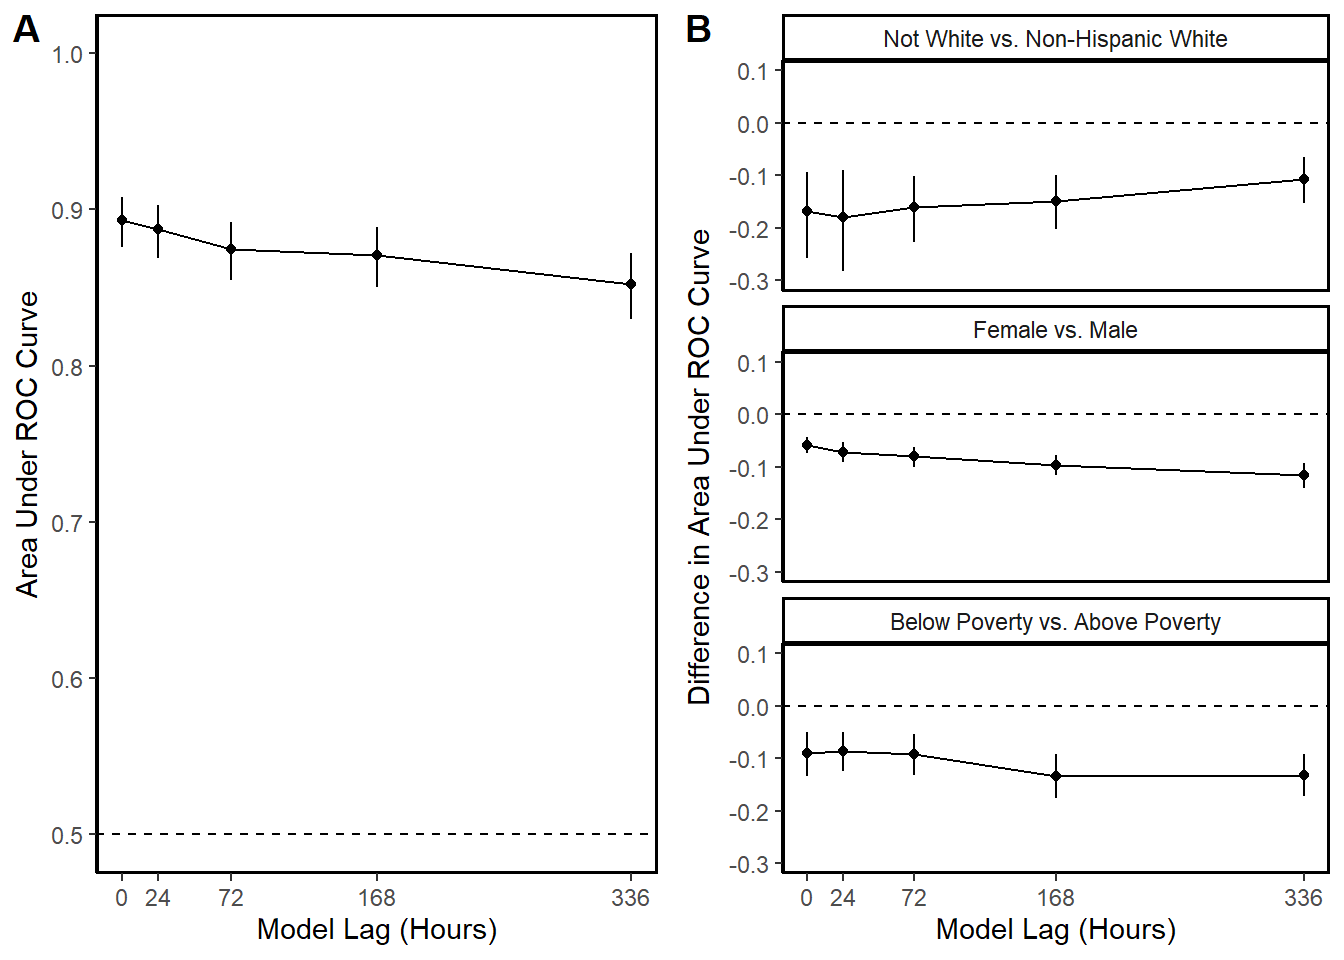

## Model Comparisons

### Baseline Contrasts

The median decrease in auROC for the baseline vs. 24 hour lag model was 0.006 (95% CI=\[0.000-0.012\]), yielding a significant probability of 0.960 that the lagged model had worse performance. The median decrease in auROC for the baseline vs. 72 hour model was 0.018 (95% CI=\[0.012-0.025\]), yielding a significant probability of 1.000 that the lagged model had worse performance. The median increase in auROC for the baseline vs. 168 hour lag model was 0.023 (95% CI=\[0.016-0.029\]), yielding a significant probability of 1.000 that the lagged model had worse performance. The median increase in auROC for the baseline vs. 336 hour lag model was 0.041 (95% CI=\[0.033-0.049\]), yielding a significant probability of 1.000 that the lagged model had worse performance.

### Adjacent Contrasts

The median decrease in auROC for the 24 hour vs. 72 hour lag model was 0.012 (95% CI=\[0.006-0.019\]), yielding a significant probability of 1.000 that the 72 hour lag model had worse performance than the 24 hour lag model. The median decrease in auROC for the 72 hour vs. 168 hour lag model was 0.004 (95% CI=\[-0.002-0.011\]), yielding a non-significant probability of 0.865 that the 168 hour lag model had worse performance than the 72 hour lag model. The median decrease in auROC for the 168 hour vs. 336 hour lag model was 0.018 (95% CI=\[0.011-0.025\]), yielding a significant probability of 1.000 that the 336 hour lag model had worse performance than the 168 hour lag model.

## Fairness Benchmarks

Panel B in @fig-1 shows the difference in performance of each model by demographic group. All group comparisons for race, sex at birth, and income were significant (probability \> .95) across models. On average there was a median increase in auROC of -0.159 (range NA–0.179) for non-Hispanic White participants compared to participants who were not White. On average there was a median increase in auROC of -0.080 (range -0.059–0.116) for male participants compared to female participants. On average there was a median increase in auROC of -0.092 (range -0.086–0.133) for participants above the federal poverty line compared to participants below the federal poverty line. A table of model performance for each demographic group separately by model can be found in the supplement.

## Feature Importance

Global importance (mean \|Shapley value\|) for feature categories for each model appears in Panel A of @fig-shap. Consistent with previous models using similar features, past use was the most important feature category for lapse prediction across lagged models. Future abstinence efficacy was also globally important across models. Overall, the contribution of a feature category to model performance did not appear to differ across models.

Panel B shows the local feature importance scores colored by high or low feature value for the 336 hour lag model. <!--comment on direction of features - ex. income. Also reference supplement with other local importance plots-->.

``` python
cowplot::plot_grid(panel_shap_global, panel_shap_local, ncol = 1, labels = c("A", "B"), align = "v")
```

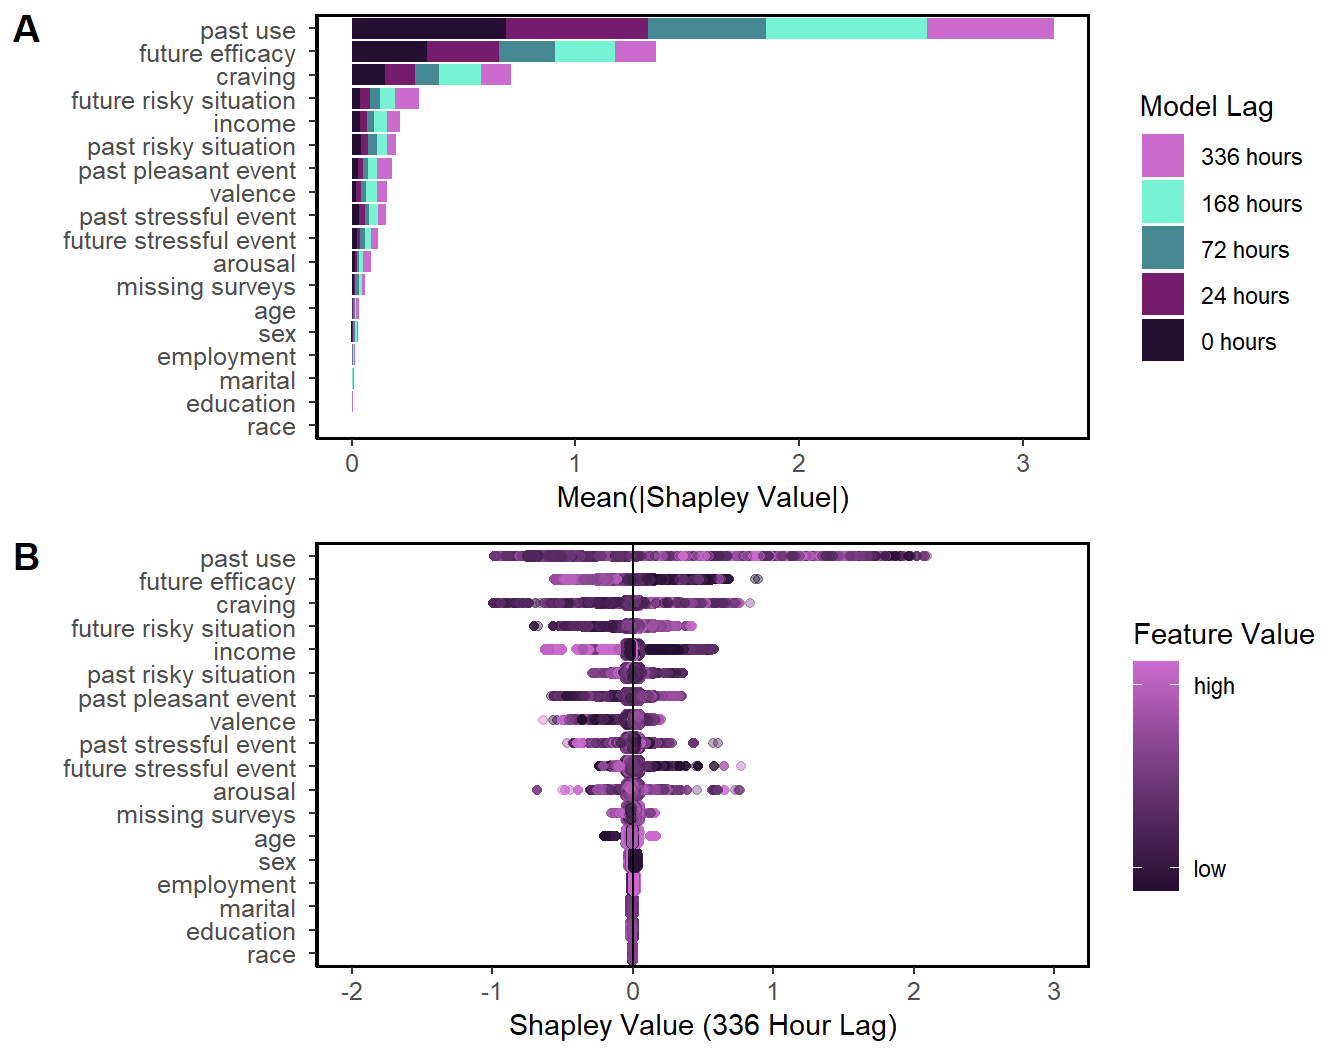

## Discussion

-   Model degrades but perhaps not meaningfully even down to two weeks out.

-   All models were worse for women and people were not white and below poverty line.

-   Improving model performance for unprivileged classes. Considering other important classes for SUD, such as geographic location, Improving diversity of training data

-   Performance discrepancies sets up fairness methods paper. How can we improve these discrepancies? Mention in discussion as current future direction

-   Note from Gaylen: if the model performance doesn’t degrade much, and the feature importance doesn’t seem to change much across lags… what does this say about the need for proximal predictors? obviously 2-3 weeks out is different than 6 months out, but even in-the-moment features are still important for predicting a lapse up to 3 weeks later (2 week lag plus 1 week window as lapse could be any time within the window). it is obviously exciting that we can do this advanced prediction, but i think you’ll have to navigate the line between celebrating that success and still calling for dense monitoring of proximal predictors

## References